## CALIDAD DE DATOS
### IMPORTAR PAQUETES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import janitor
import os
from pathlib import Path
import openpyxl
import sqlalchemy as sa


# Desactivar notación científica
pd.set_option('display.float_format', lambda x: '%.3f' % x)
np.set_printoptions(suppress=True)


# Cargar variables de entorno
load_dotenv()


print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


### VISION GENERAL DE LOS DATOS

In [2]:
# Importar train.pkl
df = pd.read_pickle('../02_datos/03_Entrenamiento/train.pkl')
print("✅ Datos cargados correctamente")
df

✅ Datos cargados correctamente


,state_id,store_id,dept_id,cat_id,item_id,wm_yr_wk,d,ventas,sell_price,year,month,wday,weekday,event_name_1,event_type_1,event_name_2,event_type_2
date,,,,,,,,,,,,,,,,,
2013-01-01,CA,CA_3,FOODS_3,FOODS,FOODS_3_090,11249,d_704,0,1.250,2013,1,4,Tuesday,NewYear,National,None,None
2013-01-01,CA,CA_3,FOODS_3,FOODS,FOODS_3_120,11249,d_704,0,4.980,2013,1,4,Tuesday,NewYear,National,None,None
2013-01-01,CA,CA_3,FOODS_3,FOODS,FOODS_3_202,11249,d_704,20,4.280,2013,1,4,Tuesday,NewYear,National,None,None
2013-01-01,CA,CA_3,FOODS_3,FOODS,FOODS_3_252,11249,d_704,34,1.480,2013,1,4,Tuesday,NewYear,National,None,None
2013-01-01,CA,CA_3,FOODS_3,FOODS,FOODS_3_288,11249,d_704,0,NaN,2013,1,4,Tuesday,NewYear,National,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-11-30,CA,CA_4,FOODS_3,FOODS,FOODS_3_329,11544,d_1767,5,2.980,2015,11,3,Monday,None,None,None,None
2015-11-30,CA,CA_4,FOODS_3,FOODS,FOODS_3_555,11544,d_1767,4,1.680,2015,11,3,Monday,None,None,None,None
2015-11-30,CA,CA_4,FOODS_3,FOODS,FOODS_3_586,11544,d_1767,9,1.680,2015,11,3,Monday,None,None,None,None


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21280 entries, 2013-01-01 to 2015-11-30
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   state_id      21280 non-null  object 
 1   store_id      21280 non-null  object 
 2   dept_id       21280 non-null  object 
 3   cat_id        21280 non-null  object 
 4   item_id       21280 non-null  object 
 5   wm_yr_wk      21280 non-null  int64  
 6   d             21280 non-null  object 
 7   ventas        21280 non-null  int64  
 8   sell_price    21209 non-null  float64
 9   year          21280 non-null  int64  
 10  month         21280 non-null  int64  
 11  wday          21280 non-null  int64  
 12  weekday       21280 non-null  object 
 13  event_name_1  1700 non-null   object 
 14  event_type_1  1700 non-null   object 
 15  event_name_2  60 non-null     object 
 16  event_type_2  60 non-null     object 
dtypes: float64(1), int64(5), object(11)
memory usage: 2.9+ MB


### TIPOS DE DATOS

In [4]:
df.dtypes

state_id         object
store_id         object
dept_id          object
cat_id           object
item_id          object
wm_yr_wk          int64
d                object
ventas            int64
sell_price      float64
year              int64
month             int64
wday              int64
weekday          object
event_name_1     object
event_type_1     object
event_name_2     object
event_type_2     object
dtype: object

##### Conclusion: year, month, ywday, deberian ser categoricas, no numericas. Esto es importante para el modelo, ya que las variables categoricas se tratan de manera diferente a las numericas. Por ejemplo, el modelo no puede interpretar el orden de los numeros en una variable categorica, por lo que es necesario convertirlas a variables dummy o one-hot encoding.

In [5]:
df = df.astype({'year': 'O', 'month': 'O', 'wday': 'O'})
df.dtypes

state_id         object
store_id         object
dept_id          object
cat_id           object
item_id          object
wm_yr_wk          int64
d                object
ventas            int64
sell_price      float64
year             object
month            object
wday             object
weekday          object
event_name_1     object
event_type_1     object
event_name_2     object
event_type_2     object
dtype: object

## VALORES UNICOS

In [6]:
df.nunique().sort_values()

state_id           1
dept_id            1
cat_id             1
store_id           2
event_type_2       2
event_name_2       3
year               3
event_type_1       4
weekday            7
wday               7
item_id           10
month             12
sell_price        23
event_name_1      30
wm_yr_wk         153
ventas           301
d               1064
dtype: int64

### Correccion

In [7]:
df.drop(columns=['state_id', 'cat_id', 'dept_id'], inplace=True)

## DUPLICADOS

In [8]:
df.duplicated().sum()

np.int64(0)

## SEPARAR NUMERICAS DE CATEGORICAS

## Categoricas

In [9]:
cat = df.select_dtypes(exclude='number').copy()

## Numericas

In [10]:
num = df.select_dtypes(include='number').copy()

## GESTION DE CATEGORICAS

## Identificacion de Nulos

In [11]:
cat.isna().sum().sort_values(ascending=False)

event_name_2    21220
event_type_2    21220
event_name_1    19580
event_type_1    19580
d                   0
store_id            0
item_id             0
weekday             0
wday                0
month               0
year                0
dtype: int64

In [12]:
cat.event_name_1.value_counts(dropna=False)

event_name_1
None                   19580
NewYear                   60
OrthodoxChristmas         60
MartinLutherKingDay       60
SuperBowl                 60
LentStart                 60
ValentinesDay             60
PresidentsDay             60
LentWeek2                 60
Purim End                 60
StPatricksDay             60
Easter                    60
Pesach End                60
Mother's day              60
MemorialDay               60
Thanksgiving              60
NBAFinalsStart            60
NBAFinalsEnd              60
IndependenceDay           60
Eid al-Fitr               60
Ramadan starts            60
LaborDay                  60
ColumbusDay               60
Halloween                 60
EidAlAdha                 60
VeteransDay               60
OrthodoxEaster            40
Father's day              40
Chanukah End              40
Christmas                 40
Cinco De Mayo             40
Name: count, dtype: int64

In [13]:
cat.event_name_2.value_counts(dropna=False)

event_name_2
None              21220
Cinco De Mayo        20
OrthodoxEaster       20
Father's day         20
Name: count, dtype: int64

In [14]:
cat.event_type_1.value_counts(dropna=False)

event_type_1
None         19580
National       580
Religious      560
Cultural       380
Sporting       180
Name: count, dtype: int64

In [15]:
cat.event_type_2.value_counts(dropna=False)

event_type_2
None         21220
Cultural        40
Religious       20
Name: count, dtype: int64

In [16]:
pd.crosstab(index=cat.event_name_1, columns=cat.event_name_2)

event_name_2,Cinco De Mayo,Father's day,OrthodoxEaster
event_name_1,,,
Easter,0,0,20
NBAFinalsEnd,0,20,0
OrthodoxEaster,20,0,0


## Conclusiones:

1. event_name_2 tiene eventos que ya estan incluidos en event_name_1, por lo que se puede eliminar.
2. al cruzar event_name_1 y event_name_2, se observa que no hay combinaciones de eventos, lo que confirma que event_name_2 es redundante.
3. como no sabemos por que vamos a eliminar event_name_2, es importante documentar esta decision en el codigo, para que otros puedan entender el razonamiento detras de esta decision.
4. en cuanto a los nulos de event_name_1 y event_type_1 parece claro que son dias "Sin evento", por lo que se pueden rellenar con "Sin evento" o "No event". Esto es importante para el modelo, ya que los nulos pueden causar problemas en el entrenamiento del modelo, y rellenarlos con un valor significativo puede mejorar el rendimiento del modelo.

## Correccion: Eliminar variables

In [17]:
cat.drop(columns=['event_name_2', 'event_type_2'], inplace=True)

## Imputar por un valor

In [18]:
var_imputar_valor = ['event_name_1', 'event_type_1']
valor = 'Sin evento'
cat[var_imputar_valor] = cat[var_imputar_valor].fillna(valor)

## Comprobamos que no hay nulos

In [19]:
cat.isna().sum().sort_values(ascending=False)

store_id        0
item_id         0
d               0
year            0
month           0
wday            0
weekday         0
event_name_1    0
event_type_1    0
dtype: int64

## Atipicos

## Categorias poco frecuentes

In [20]:
for variable in cat:
    print(f"Variable: {variable}")
    print(cat[variable].value_counts(dropna=False))
    print("\n")

Variable: store_id
store_id
CA_3    10640
CA_4    10640
Name: count, dtype: int64


Variable: item_id
item_id
FOODS_3_090    2128
FOODS_3_120    2128
FOODS_3_202    2128
FOODS_3_252    2128
FOODS_3_288    2128
FOODS_3_329    2128
FOODS_3_555    2128
FOODS_3_586    2128
FOODS_3_587    2128
FOODS_3_714    2128
Name: count, dtype: int64


Variable: d
d
d_1767    20
d_704     20
d_705     20
d_706     20
d_707     20
          ..
d_716     20
d_715     20
d_714     20
d_713     20
d_712     20
Name: count, Length: 1064, dtype: int64


Variable: year
year
2013    7300
2014    7300
2015    6680
Name: count, dtype: int64


Variable: month
month
1     1860
3     1860
7     1860
5     1860
8     1860
10    1860
6     1800
4     1800
11    1800
9     1800
2     1680
12    1240
Name: count, dtype: int64


Variable: wday
wday
4    3040
5    3040
6    3040
7    3040
1    3040
2    3040
3    3040
Name: count, dtype: int64


Variable: weekday
weekday
Tuesday      3040
Wednesday    3040
Thursday     3

## Conclusiones:
1. No hay variables con categorias raras
2. Hay meses con menos registros, eso puede ser porque son los meses con menos de 31 dias.
3. 2015 tiene menos registros, por validacion o hay algo mas?

Vamos a investigar esto ultimo, ya que puede ser importante para el modelo, si hay un sesgo en los datos de 2015, el modelo puede aprender ese sesgo y no generalizar bien a otros años.

In [21]:
df.groupby('year').d.unique()


year
2013    [d_704, d_705, d_706, d_707, d_708, d_709, d_7...
2014    [d_1069, d_1070, d_1071, d_1072, d_1073, d_107...
2015    [d_1434, d_1435, d_1436, d_1437, d_1438, d_143...
Name: d, dtype: object

#### Faltan justamente 31 dias de diciembre, los que seleccionamos para validacion

## GESTION DE NUMERICAS

### Estadisticas de las variables numericas

In [22]:
num.describe().T

,count,mean,std,min,25%,50%,75%,max
wm_yr_wk,21280.000,11415.023,82.875,11249.000,11335.000,11420.000,11506.000,11544.000
ventas,21280.000,28.875,38.988,0.000,6.000,18.000,37.000,763.000
sell_price,21209.000,2.397,1.237,1.000,1.500,1.580,2.980,4.980


### Nulos

### Identificacion de nulos

In [23]:
num.isna().sum().sort_values(ascending=False)

sell_price    71
wm_yr_wk       0
ventas         0
dtype: int64

#### sell_price es una variable relevante, vamos a investigar si hay algun patron en los nulos de esta variable

In [24]:
# Por producto
df.groupby('item_id')['sell_price'].apply(lambda x: x.isna().sum()).sort_values(ascending=False)

item_id
FOODS_3_288    71
FOODS_3_090     0
FOODS_3_120     0
FOODS_3_202     0
FOODS_3_252     0
FOODS_3_329     0
FOODS_3_555     0
FOODS_3_586     0
FOODS_3_587     0
FOODS_3_714     0
Name: sell_price, dtype: int64

In [25]:
df.groupby('ventas').sell_price.apply(lambda x: x.isna().sum()).sort_values(ascending=False)

ventas
0     71
4      0
5      0
6      0
7      0
      ..
24     0
25     0
26     0
27     0
2      0
Name: sell_price, Length: 301, dtype: int64

#### Solo pasa en un producto y solo los dias en los que no hay ventas. Claramente el motivo es que si no hay ventas, no le ponen precio, por lo que tenemos que corregir ya que es artificial, ya que el producto tiene precio asi no se haya vendido en determinado dia. Vamos a imputar el precio de ese producto por el primer valor valido anterior SEGMENTADO POR PRODUCTO. Pero podria pasar que el primer dia de un producto tuviera ventas cero, lo cual arrastraria los nulos hacia adelante sin solucionar el problema, asi que vamos a imputar por el valor mas frecuente de precio de cada producto en cada semana, es decir, por medio de la moda. Esto anade complejidad, ya que necesitamos el producto que no lo tenemos en num. Asi que tenemos que incluirlo temporalmente y despues eliminarlo.

In [26]:
num = pd.concat([num, cat.item_id], axis=1)
num

,wm_yr_wk,ventas,sell_price,item_id
date,,,,
2013-01-01,11249,0,1.250,FOODS_3_090
2013-01-01,11249,0,4.980,FOODS_3_120
2013-01-01,11249,20,4.280,FOODS_3_202
2013-01-01,11249,34,1.480,FOODS_3_252
2013-01-01,11249,0,NaN,FOODS_3_288
...,...,...,...,...
2015-11-30,11544,5,2.980,FOODS_3_329
2015-11-30,11544,4,1.680,FOODS_3_555
2015-11-30,11544,9,1.680,FOODS_3_586


#### Correccion de nulos de sell_price
#### Calcular el precio mas frecuente de cada producto en cada semana
#### Imputar los nulos de sell_price por el precio mas frecuente de cada producto en

In [27]:
def imputar_moda(registros):
    # Calcular la moda de sell_price para el grupo semana-grupo
    moda_serie = registros['sell_price'].mode()
    if not moda_serie.empty:
        moda = moda_serie.iloc[0]
    else:
        # Si no hay moda, calcularla a nivel de producto
        item_id = registros['item_id'].iloc[0]
        moda_producto = num[num['item_id'] == item_id]['sell_price'].mode()
        if not moda_producto.empty:
            moda = moda_producto.iloc[0]
        else:
            # Si no hay moda a nivel de producto, usar un valor predeterminado (por ejemplo, 0)
            moda = np.nan
    registros.loc[registros['sell_price'].isna(), 'sell_price'] = moda
    return registros

num = num.groupby(['wm_yr_wk', 'item_id'], group_keys=False).apply(imputar_moda)

C:\Users\robin\AppData\Local\Temp\ipykernel_30860\3037014462.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  num = num.groupby(['wm_yr_wk', 'item_id'], group_keys=False).apply(imputar_moda)


#### Para comprobar que la imputacion se ha hecho corectamente por producto, podemos revisar los valores distintos de precio en cada producto y ver que no haya un salto grande, por ejemplo de 3 a 10

In [28]:
num.groupby('item_id')['sell_price'].unique()

item_id
FOODS_3_090                 [1.25, 1.38, 1.0, 1.44, 1.48, 1.5]
FOODS_3_120                                             [4.98]
FOODS_3_202    [4.28, 3.98, 3.25, 4.38, 3.0, 4.58, 3.33, 4.48]
FOODS_3_252                                       [1.48, 1.58]
FOODS_3_288                                  [1.5, 1.18, 1.25]
FOODS_3_329                                 [2.98, 2.74, 1.98]
FOODS_3_555                                       [1.58, 1.68]
FOODS_3_586                                       [1.58, 1.68]
FOODS_3_587                                 [2.68, 2.48, 1.98]
FOODS_3_714                                       [1.48, 1.58]
Name: sell_price, dtype: object

#### Eliminar el producto que habiamos incluido temporalmente para la imputacion

In [29]:
num.drop(columns=['item_id'], inplace=True)

In [30]:
num.head()

,wm_yr_wk,ventas,sell_price
date,,,
2013-01-01,11249,0,1.250
2013-01-01,11249,33,1.250
2013-01-01,11249,0,4.980
2013-01-01,11249,0,4.980
2013-01-01,11249,20,4.280


#### Atipicos

#### Identificacion por desviacion tipica

In [31]:
num_desv_tip = 4

In [32]:
def atipicos_desv_tip(variable, num_desv_tip = 4):
    # Sacamos los nulos por ahora
    variable = variable.dropna()
    # Calculamos los limites
    media = np.mean(variable)
    sd = np.std(variable)
    umbral = sd * num_desv_tip
    lim_inf = media - umbral
    lim_sup = media + umbral
    # Encontramos los indices de los que estan fuera de los limites
    indices = [indice for indice, valor in variable.items() if valor < lim_inf or valor > lim_sup]
    return(indices)

In [33]:
def conteo_atipicos(df, variable, num_desv_tip):
    atipicos = atipicos_desv_tip(df[variable], num_desv_tip)
    return(df.loc[atipicos, variable].value_counts())

In [34]:
var_atipicos_dt = ['ventas', 'sell_price']

In [35]:
for variable in var_atipicos_dt:
    print('\n' + variable + ':\n')
    print(conteo_atipicos(num, variable, num_desv_tip))


ventas:

ventas
0      518
1      103
5      100
10      95
7       92
      ... 
158      1
139      1
103      1
107      1
323      1
Name: count, Length: 247, dtype: int64

sell_price:

Series([], Name: count, dtype: int64)


##### Parece que son atipicos superiores

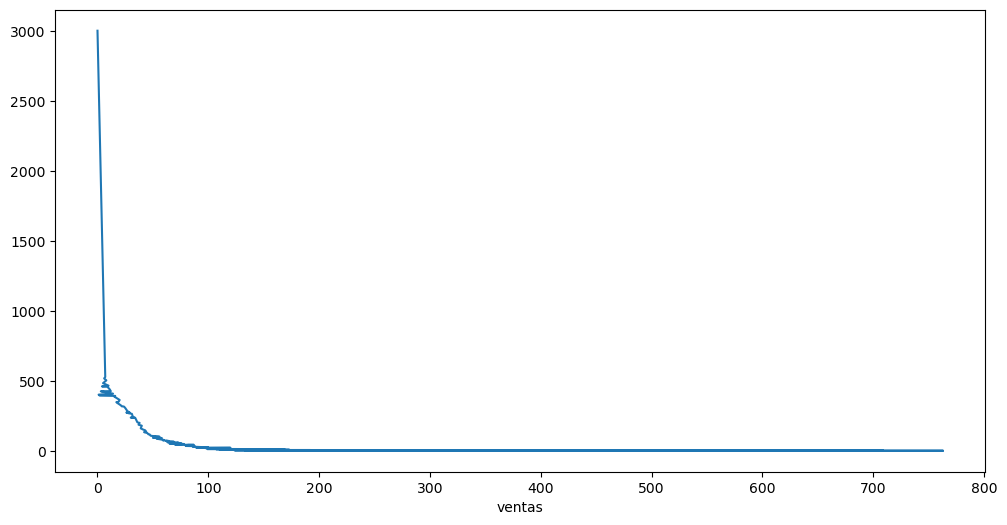

In [36]:
num.ventas.value_counts().plot(figsize = (12, 6));

#### Conclusion:
1) Es un claro ejemplo de cola larga, que es muy frecuente en retail.
2) Mejor no hacer nada por ahora en cuanto a atipicos, en EDA quiza lo veamos mejor.

## GUARDAR DATASETS TRAS CALIDAD DE DATOS

#### Guarda los avances en df, cat y num con un sufijo para poder guardar o recuperar avances del proyecto, en formato pickle para no perder las modificaciones.

In [37]:
df.to_pickle("../02_datos/03_Entrenamiento/train_resultado_calidad.pkl")
cat.to_pickle("../02_datos/03_Entrenamiento/cat_resultado_calidad.pkl")
num.to_pickle("../02_datos/03_Entrenamiento/num_resultado_calidad.pkl")